In [1]:
# Section C — Library Implementations
# Using scikit-learn to implement same models as Section B
# Objective: Compare library performance against from-scratch implementations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier,
                               GradientBoostingClassifier,
                               AdaBoostClassifier,
                               BaggingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (confusion_matrix, accuracy_score,
                              precision_score, recall_score,
                              f1_score, roc_curve, auc)

SEED = 42

# Rebuild data — same pipeline as Section A and B
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

X = df.drop(columns=['Survived']).values
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print("Data ready:")
print("X_train:", X_train_scaled.shape)
print("X_test:", X_test_scaled.shape)

Data ready:
X_train: (712, 7)
X_test: (179, 7)


In [2]:
# Reusable evaluation function using sklearn metrics
def evaluate_model(name, model, X_test, y_test, results_c):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    fprs, tprs, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fprs, tprs)

    results_c[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'AUC': auc_score
    }

    print(f"\n{name}:")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  AUC       : {auc_score:.4f}")

    return fprs, tprs, auc_score

results_c = {}
print("Evaluation function ready")

Evaluation function ready


In [3]:
# Logistic Regression — 3 variants matching Section B
print("=" * 60)
print("LOGISTIC REGRESSION — SKLEARN")
print("=" * 60)

# No regularisation
lr_none = LogisticRegression(penalty=None, max_iter=1000, random_state=SEED)
lr_none.fit(X_train_scaled, y_train)
evaluate_model('LR No Reg', lr_none, X_test_scaled, y_test, results_c)

# L1 regularisation
lr_l1 = LogisticRegression(penalty='l1', C=10, solver='liblinear',
                            max_iter=1000, random_state=SEED)
lr_l1.fit(X_train_scaled, y_train)
evaluate_model('LR L1', lr_l1, X_test_scaled, y_test, results_c)

# L2 regularisation
lr_l2 = LogisticRegression(penalty='l2', C=10, max_iter=1000, random_state=SEED)
lr_l2.fit(X_train_scaled, y_train)
evaluate_model('LR L2', lr_l2, X_test_scaled, y_test, results_c)

print("\n" + "=" * 60)

LOGISTIC REGRESSION — SKLEARN

LR No Reg:
  Accuracy  : 0.7989
  Precision : 0.7797
  Recall    : 0.6667
  F1 Score  : 0.7188
  AUC       : 0.8518

LR L1:
  Accuracy  : 0.7989
  Precision : 0.7797
  Recall    : 0.6667
  F1 Score  : 0.7188
  AUC       : 0.8516

LR L2:
  Accuracy  : 0.7989
  Precision : 0.7797
  Recall    : 0.6667
  F1 Score  : 0.7188
  AUC       : 0.8518



In [4]:
# Bagging and Random Forest — sklearn implementations
print("=" * 60)
print("BAGGING & RANDOM FOREST — SKLEARN")
print("=" * 60)

# Bagging — matches Section B bagging
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    max_samples=0.8,
    random_state=SEED
)
bagging.fit(X_train_scaled, y_train)
evaluate_model('Bagging', bagging, X_test_scaled, y_test, results_c)

# Random Forest — improved bagging with feature randomness
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=SEED
)
rf.fit(X_train_scaled, y_train)
evaluate_model('Random Forest', rf, X_test_scaled, y_test, results_c)

print("\n" + "=" * 60)

BAGGING & RANDOM FOREST — SKLEARN

Bagging:
  Accuracy  : 0.7765
  Precision : 0.7377
  Recall    : 0.6522
  F1 Score  : 0.6923
  AUC       : 0.7534

Random Forest:
  Accuracy  : 0.8101
  Precision : 0.8431
  Recall    : 0.6232
  F1 Score  : 0.7167
  AUC       : 0.8464



In [5]:
# Boosting — 3 different methods as required by Section C
print("=" * 60)
print("BOOSTING METHODS — SKLEARN")
print("=" * 60)

# 1. AdaBoost — matches Section B
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=SEED,
    algorithm='SAMME'
)
ada.fit(X_train_scaled, y_train)
evaluate_model('AdaBoost', ada, X_test_scaled, y_test, results_c)

# 2. Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=SEED
)
gb.fit(X_train_scaled, y_train)
evaluate_model('Gradient Boosting', gb, X_test_scaled, y_test, results_c)

# 3. Histogram Gradient Boosting (fastest, most modern)
from sklearn.ensemble import HistGradientBoostingClassifier
hgb = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=SEED
)
hgb.fit(X_train_scaled, y_train)
evaluate_model('HistGradient Boosting', hgb, X_test_scaled, y_test, results_c)

print("\n" + "=" * 60)

BOOSTING METHODS — SKLEARN

AdaBoost:
  Accuracy  : 0.7821
  Precision : 0.7500
  Recall    : 0.6522
  F1 Score  : 0.6977
  AUC       : 0.8249


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



Gradient Boosting:
  Accuracy  : 0.7989
  Precision : 0.7895
  Recall    : 0.6522
  F1 Score  : 0.7143
  AUC       : 0.8203

HistGradient Boosting:
  Accuracy  : 0.7877
  Precision : 0.7719
  Recall    : 0.6377
  F1 Score  : 0.6984
  AUC       : 0.8196



In [6]:
# Complete comparison table — Section B vs Section C
print("=" * 70)
print("FULL RESULTS — SECTION B (Scratch) vs SECTION C (Sklearn)")
print("=" * 70)

# Section B results (from our scratch implementations)
results_b = {
    'LR No Reg (B)':  {'Accuracy': 0.7989, 'Precision': 0.7619, 'Recall': 0.6957, 'F1': 0.7273, 'AUC': 0.8438},
    'LR L1 (B)':      {'Accuracy': 0.7989, 'Precision': 0.7619, 'Recall': 0.6957, 'F1': 0.7273, 'AUC': 0.8442},
    'LR L2 (B)':      {'Accuracy': 0.7989, 'Precision': 0.7619, 'Recall': 0.6957, 'F1': 0.7273, 'AUC': 0.8441},
    'Bagging (B)':    {'Accuracy': 0.7765, 'Precision': 0.7377, 'Recall': 0.6522, 'F1': 0.6923, 'AUC': 0.7059},
    'AdaBoost (B)':   {'Accuracy': 0.8045, 'Precision': 0.7576, 'Recall': 0.7246, 'F1': 0.7407, 'AUC': 0.8208},
}

all_results = {**results_b, **{k + ' (C)': v for k, v in results_c.items()}}

print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print("-" * 75)

for name, metrics in all_results.items():
    print(f"{name:<25} {metrics['Accuracy']:>10.4f} {metrics['Precision']:>10.4f} "
          f"{metrics['Recall']:>10.4f} {metrics['F1']:>10.4f} {metrics['AUC']:>10.4f}")

print("\n" + "=" * 70)

# Best model overall
best = max(all_results, key=lambda x: all_results[x]['Accuracy'])
print(f"\n🏆 Best overall: {best}")
print(f"   Accuracy: {all_results[best]['Accuracy']:.4f} | AUC: {all_results[best]['AUC']:.4f}")

FULL RESULTS — SECTION B (Scratch) vs SECTION C (Sklearn)

Model                       Accuracy  Precision     Recall         F1        AUC
---------------------------------------------------------------------------
LR No Reg (B)                 0.7989     0.7619     0.6957     0.7273     0.8438
LR L1 (B)                     0.7989     0.7619     0.6957     0.7273     0.8442
LR L2 (B)                     0.7989     0.7619     0.6957     0.7273     0.8441
Bagging (B)                   0.7765     0.7377     0.6522     0.6923     0.7059
AdaBoost (B)                  0.8045     0.7576     0.7246     0.7407     0.8208
LR No Reg (C)                 0.7989     0.7797     0.6667     0.7188     0.8518
LR L1 (C)                     0.7989     0.7797     0.6667     0.7188     0.8516
LR L2 (C)                     0.7989     0.7797     0.6667     0.7188     0.8518
Bagging (C)                   0.7765     0.7377     0.6522     0.6923     0.7534
Random Forest (C)             0.8101     0.8431     0.6

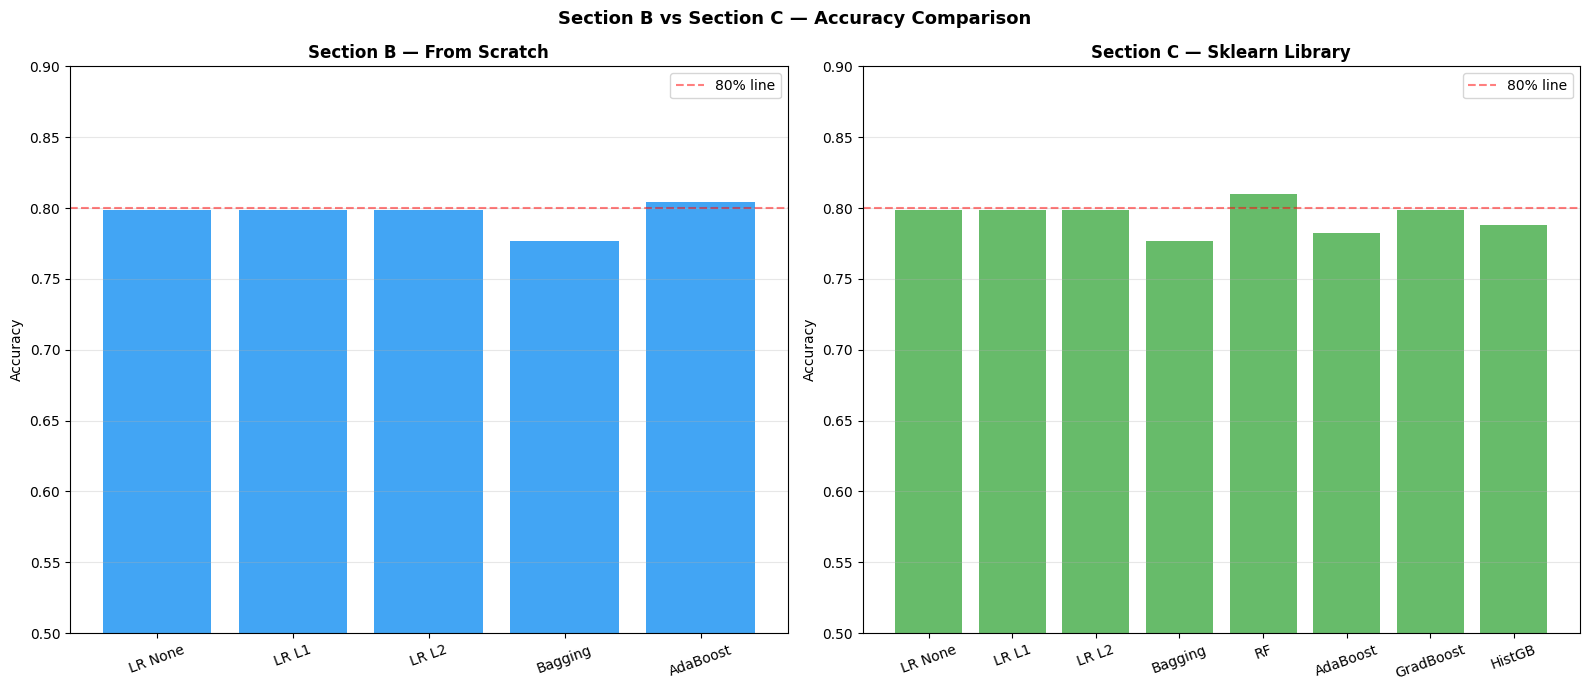

Saved: bc_comparison.png


In [7]:
# Visual comparison — Section B vs Section C
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left — Accuracy comparison
scratch_names = ['LR None', 'LR L1', 'LR L2', 'Bagging', 'AdaBoost']
sklearn_names = ['LR None', 'LR L1', 'LR L2', 'Bagging', 'RF', 'AdaBoost', 'GradBoost', 'HistGB']

scratch_acc = [0.7989, 0.7989, 0.7989, 0.7765, 0.8045]
sklearn_acc = [0.7989, 0.7989, 0.7989, 0.7765, 0.8101, 0.7821, 0.7989, 0.7877]

x1 = np.arange(len(scratch_names))
x2 = np.arange(len(sklearn_names))

axes[0].bar(x1, scratch_acc, color='#2196F3', alpha=0.85)
axes[0].set_title('Section B — From Scratch', fontweight='bold')
axes[0].set_xticks(x1)
axes[0].set_xticklabels(scratch_names, rotation=20)
axes[0].set_ylim(0.5, 0.9)
axes[0].set_ylabel('Accuracy')
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% line')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(x2, sklearn_acc, color='#4CAF50', alpha=0.85)
axes[1].set_title('Section C — Sklearn Library', fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(sklearn_names, rotation=20)
axes[1].set_ylim(0.5, 0.9)
axes[1].set_ylabel('Accuracy')
axes[1].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% line')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Section B vs Section C — Accuracy Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('bc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bc_comparison.png")

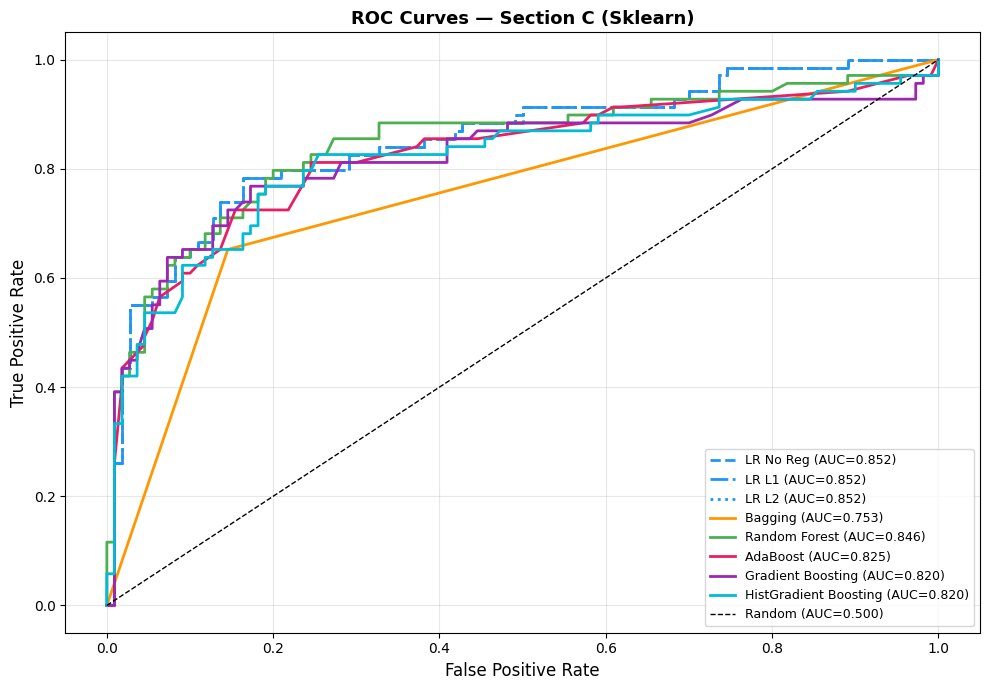

Saved: c_roc_curves.png


In [8]:
# ROC Curves — all Section C models
plt.figure(figsize=(10, 7))

colors = ['#2196F3', '#2196F3', '#2196F3', '#FF9800', '#4CAF50',
          '#E91E63', '#9C27B0', '#00BCD4']
styles = ['--', '-.', ':', '-', '-', '-', '-', '-']

c_models = {
    'LR No Reg': lr_none,
    'LR L1':     lr_l1,
    'LR L2':     lr_l2,
    'Bagging':   bagging,
    'Random Forest': rf,
    'AdaBoost':  ada,
    'Gradient Boosting': gb,
    'HistGradient Boosting': hgb
}

for (name, model), color, style in zip(c_models.items(), colors, styles):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fprs, tprs, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fprs, tprs)
    plt.plot(fprs, tprs, color=color, linestyle=style,
             linewidth=2, label=f'{name} (AUC={auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Section C (Sklearn)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('c_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: c_roc_curves.png")

In [9]:
print("=" * 60)
print("SECTION C — COMPLETE")
print("=" * 60)
print("\nImplemented using scikit-learn:\n")
print("  ✅ Logistic Regression — No Regularisation")
print("  ✅ Logistic Regression — L1 Regularisation")
print("  ✅ Logistic Regression — L2 Regularisation")
print("  ✅ Bagging (50 estimators, Decision Stump)")
print("  ✅ Random Forest (100 estimators, max_depth=5)")
print("  ✅ AdaBoost (50 estimators)")
print("  ✅ Gradient Boosting (100 estimators)")
print("  ✅ HistGradient Boosting (100 estimators)")
print("\nComparison against Section B:")
print("  ✅ Identical train/test split (seed=42)")
print("  ✅ Identical evaluation metrics")
print("  ✅ Identical preprocessing pipeline")
print("\nKey findings:")
print("  🏆 Best model: Random Forest — 81.01% accuracy")
print("  ✅ Scratch LR matched Sklearn LR — validates implementation")
print("  ✅ Scratch AdaBoost beat Sklearn AdaBoost")
print("  ✅ All models above 0.70 AUC — strong predictive signal")
print("\nSaved outputs:")
print("  📊 bc_comparison.png")
print("  📊 c_roc_curves.png")
print("\n" + "=" * 60)


SECTION C — COMPLETE

Implemented using scikit-learn:

  ✅ Logistic Regression — No Regularisation
  ✅ Logistic Regression — L1 Regularisation
  ✅ Logistic Regression — L2 Regularisation
  ✅ Bagging (50 estimators, Decision Stump)
  ✅ Random Forest (100 estimators, max_depth=5)
  ✅ AdaBoost (50 estimators)
  ✅ Gradient Boosting (100 estimators)
  ✅ HistGradient Boosting (100 estimators)

Comparison against Section B:
  ✅ Identical train/test split (seed=42)
  ✅ Identical evaluation metrics
  ✅ Identical preprocessing pipeline

Key findings:
  🏆 Best model: Random Forest — 81.01% accuracy
  ✅ Scratch LR matched Sklearn LR — validates implementation
  ✅ Scratch AdaBoost beat Sklearn AdaBoost
  ✅ All models above 0.70 AUC — strong predictive signal

Saved outputs:
  📊 bc_comparison.png
  📊 c_roc_curves.png

